In [16]:
from animal_results import AnimalResults
from utilities import get_p_value, draw_l2_histogram, draw_p_value_histogram

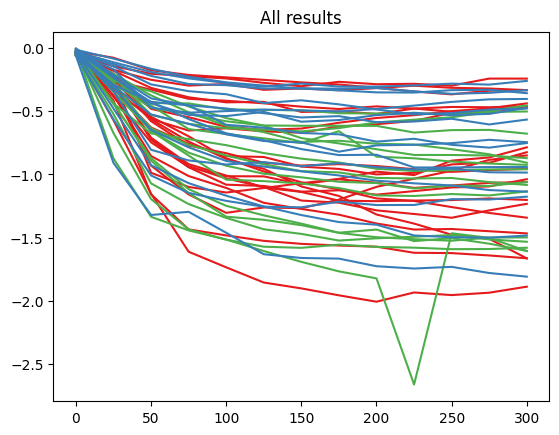

In [17]:
animal_results = AnimalResults.from_csv("FEPSP_CA1.csv")
animal_results.plot("All results")

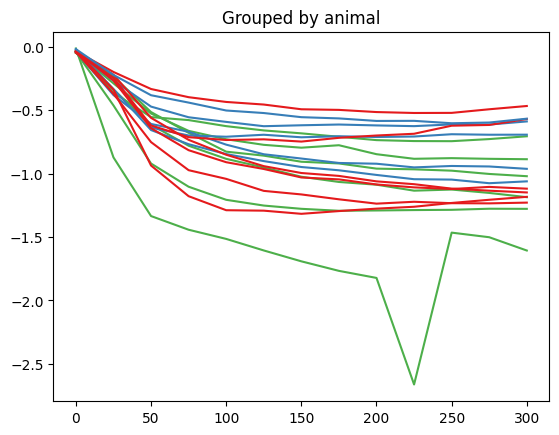

In [18]:
grouped_by_animal = animal_results.group_by_animal()
grouped_by_animal.plot("Grouped by animal")

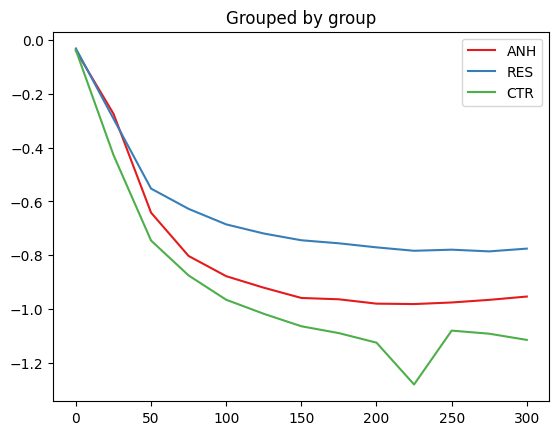

In [19]:
grouped_by_group = grouped_by_animal.group_by_group()
grouped_by_group.plot("Grouped by group")

In [20]:
l2 = grouped_by_group.get_l2()
l2

9.29907449064013

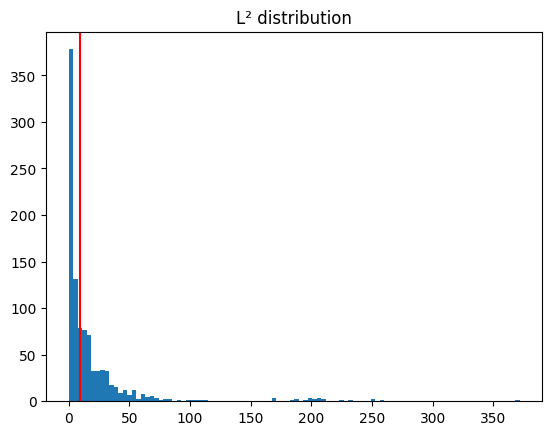

In [21]:
randomized_group_l2s = [grouped_by_animal.randomize_groups().group_by_group().get_l2() for _ in range(1000)]
draw_l2_histogram(results=randomized_group_l2s, threshold=l2, bin_count=100, title="L² distribution")

In [22]:
get_p_value(randomized_group_l2s, l2)

0.451

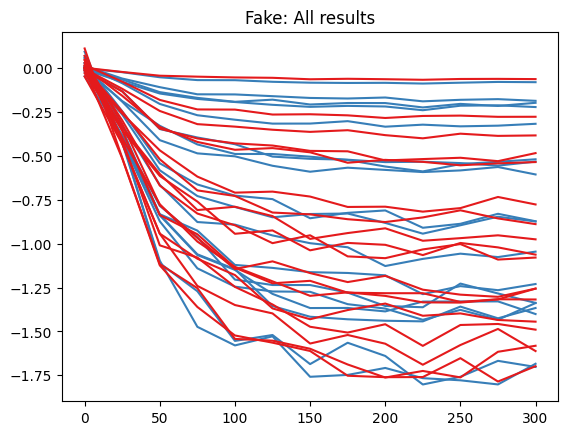

In [23]:
fake_animal_results = animal_results.to_fake()
fake_animal_results.plot("Fake: All results")

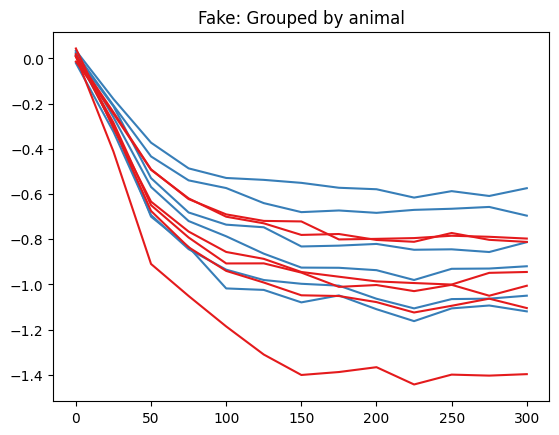

In [24]:
fake_grouped_by_animal = fake_animal_results.group_by_animal()
fake_grouped_by_animal.plot("Fake: Grouped by animal")

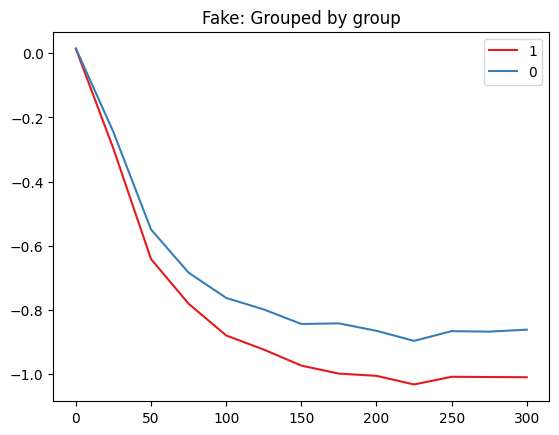

In [25]:
fake_grouped_by_group = fake_grouped_by_animal.group_by_group()
fake_grouped_by_group.plot("Fake: Grouped by group")

In [26]:
fake_l2 = fake_grouped_by_group.get_l2()
fake_l2

4.495977079451576

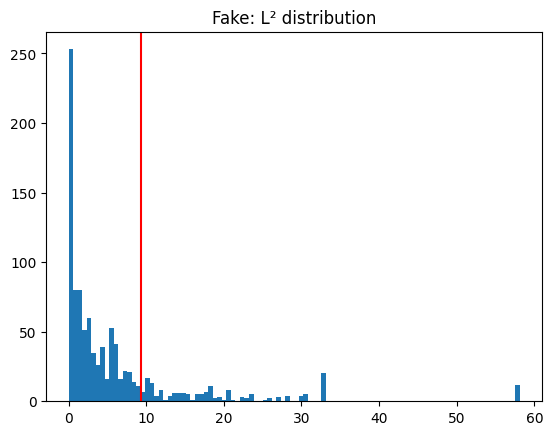

In [27]:
fake_randomized_group_l2s = [fake_grouped_by_animal.randomize_groups().group_by_group().get_l2() for _ in range(1000)]
draw_l2_histogram(results=fake_randomized_group_l2s, threshold=l2, bin_count=100, title="Fake: L² distribution")

In [28]:
get_p_value(fake_randomized_group_l2s, fake_l2)

0.382

In [29]:
fake_p_values = []
for _ in range(1000):
    fake_animal_results = animal_results.to_fake()
    fake_grouped_by_animal = fake_animal_results.group_by_animal()
    fake_grouped_by_group = fake_grouped_by_animal.group_by_group()
    fake_l2 = fake_grouped_by_group.get_l2()
    fake_randomized_group_l2s = [
        fake_grouped_by_animal.randomize_groups().group_by_group().get_l2()
        for _ in range(1000)
    ]
    fake_p_values.append(get_p_value(fake_randomized_group_l2s, fake_l2))

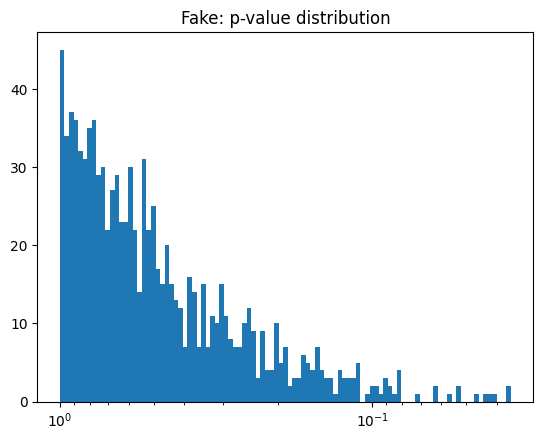

In [35]:
draw_p_value_histogram(results=fake_p_values, bin_count=100, title="Fake: p-value distribution")

In [31]:
len([fpv for fpv in fake_p_values if fpv < 0.05])

6

In [32]:
len([fpv for fpv in fake_p_values if fpv < 0.01])

0

In [33]:
len([fpv for fpv in fake_p_values if fpv < 0.001])

0